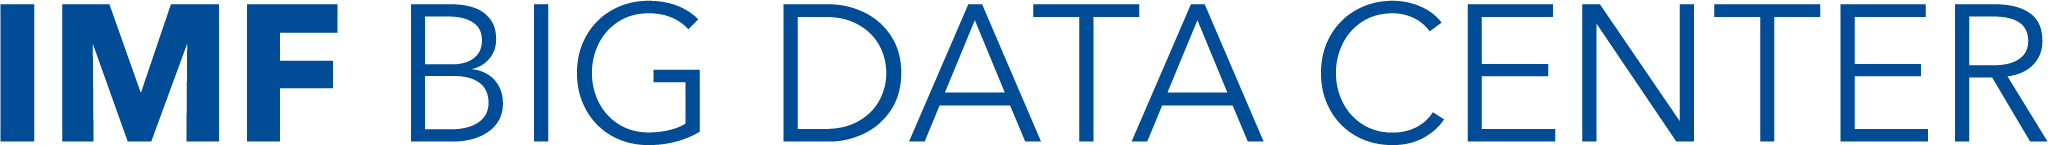

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/STI_2026/blob/main/notebooks/BDC_Data_Preprocessing_for_GDP_Nowcasting.ipynb)

# Satellite data extraction and preprocessing for GDP nowcasting

---

<br>**Contributors:** [Iyke Maduako](imaduako@imf.org), [Alberto Sanchez](asanchez3@imf.org), [Alessandra Sozzi](asozzi@imf.org)
<br> **Last update:** 2025-10-23 (Created: 2025-May)
<br> **Description:** This notebook shows how to access, download, process and save data to feed Nowcasting models.
<br> **References:**

## Set-up

Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [ ]:
import ee
import geemap.foliumap as geemap
from geemap import cartoee
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

cartopy is not installed. Please see https://scitools.org.uk/cartopy/docs/latest/installing.html#installing for instructions on how to install cartopy.

The easiest way to install cartopy is using conda: conda install -c conda-forge cartopy


### Define scope

Country of interest

In [ ]:
CountryName="Nigeria"
CountryCode="NGA"

Time range

In [ ]:
startYear = 2010
endYear = 2025

### Authenticate to GEE

⏰**Enter your Google Cloud project name**

In [ ]:
ee.Authenticate()
my_project_name = 'ee-bigdatacenter-1' # USE YOUR OWN GOOGLE CLOUD PROJECT
ee.Initialize(project=my_project_name)

## Extract Satellite Data

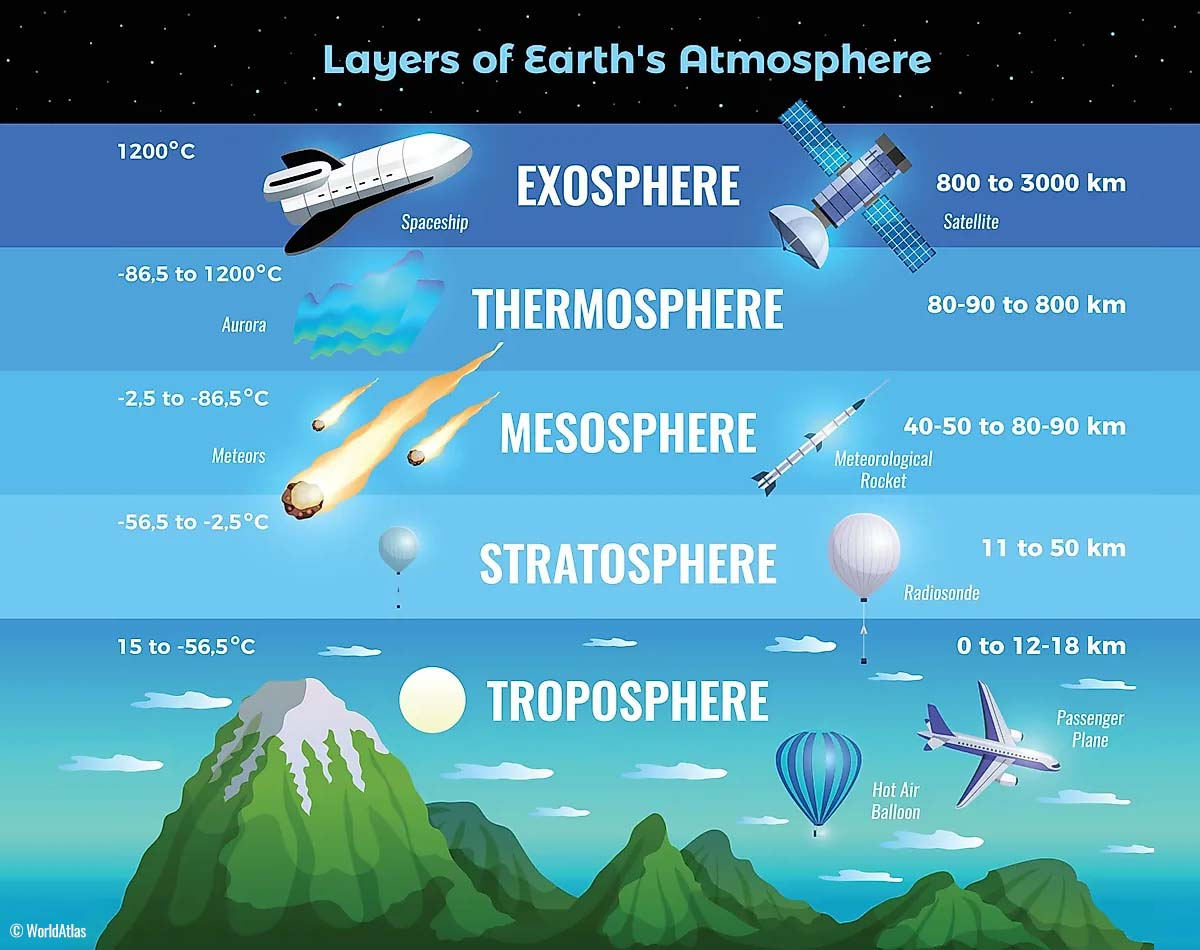

⚠ ***NOTE: Data extraction can take a long time. We will skip this part during the workshop. Feel free to try on your own***

### **Extract NO2 data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Define the country name

# Select the Sentinel-5P NO2 dataset
dataset = ee.ImageCollection("COPERNICUS/S5P/NRTI/L3_NO2")

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean tropospheric_NO2_column_number_density
        temporalReducer = ee.Reducer.sum()
        # scale: in meters of the projection to work in
        # maxPixels: maximum number of pixels to reduce
        # crs: If unspecified, the projection of the image's first band is used. If specified in addition to scale, rescaled to the specified scale.
        stats3 = filteredDataset.select("tropospheric_NO2_column_number_density").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("tropospheric_NO2_column_number_density_sum_sum")
            mean_avg = stats.get("tropospheric_NO2_column_number_density_sum_mean")
            #print(sum_avg)

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "Sum_tropospheric_NO2_column_number_density":sum_avg.getInfo() if sum_avg != "NA" else None,
            "Mean_tropospheric_NO2_column_number_density": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df


KeyboardInterrupt: 

In [ ]:
# Save the data: Uncomment as needed
file_path1 = f"{CountryName}_NO2_{startYear}_{endYear}.csv"
df.to_csv(file_path1, index=False)

### **Extract NDVI data**

In [1]:

# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the MOD13A3 dataset
dataset = ee.ImageCollection("MODIS/061/MOD13A3").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean NDVI
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("NDVI").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("sum_ndvi_sum")
            mean_avg = stats.get("sum_mean_ndvi")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "sum_ndvi": sum_avg.getInfo() if sum_avg != "NA" else None,
            "mean_ndvi": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df


NameError: name 'ee' is not defined

In [ ]:
# Save the data: Uncomment as needed
file_path3 = f"{CountryName}_NDVI_Stats_{startYear}_{endYear}.csv"
df.to_csv(file_path3, index=False)

### **Extract EVI data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the MOD13A3 dataset
dataset = ee.ImageCollection("MODIS/061/MOD13A3").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean EVI
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("EVI").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("sum_evi_sum")
            mean_avg = stats.get("sum_mean_evi")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "sum_evi": sum_avg.getInfo() if sum_avg != "NA" else None,
            "mean_evi": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df


In [ ]:

# Save the data: Uncomment as needed
file_path4 = f"{CountryName}_EVI_Stats_{startYear}_{endYear}.csv"
df.to_csv(file_path4, index=False)

### **Extract Nighttime Lights data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the VIIRS NTL dataset
dataset = ee.ImageCollection("NASA/VIIRS/002/VNP46A2").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean Gap_Filled_DNB_BRDF_Corrected_NTL
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("Gap_Filled_DNB_BRDF_Corrected_NTL").reduce(temporalReducer)
        # scale: in meters of the projection to work in
        # maxPixels: maximum number of pixels to reduce
        # crs: If unspecified, the projection of the image's first band is used. If specified in addition to scale, rescaled to the specified scale.
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("Gap_Filled_DNB_BRDF_Corrected_sum_ntl_sum")
            mean_avg = stats.get("Gap_Filled_DNB_BRDF_Corrected_sum_mean_ntl")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "Sum_Gap_Filled_DNB_BRDF_Corrected_NTL": sum_avg.getInfo() if sum_avg != "NA" else None,
            "Mean_Gap_Filled_DNB_BRDF_Corrected_NTL": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df



In [ ]:

# Save the data: Uncomment as needed
file_path1 = f"{CountryName}_NTL{startYear}_{endYear}.csv"
df.to_csv(file_path1, index=False)

### **Extract precipitation data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the MOD13A3 dataset
dataset = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean precipitation
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("precipitation").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("precipitation_sum_sum")
            mean_avg = stats.get("precipitation_sum_mean")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "Sum_precipitation": sum_avg.getInfo() if sum_avg != "NA" else None,
            "Mean_precipitation": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df




In [ ]:
# Save the data: Uncomment as needed
file_path4 = f"{CountryName}_precipitation_Stats_{startYear}_{endYear}.csv"
df.to_csv(file_path4, index=False)

### **Extract agricultural indicators from FAO**

In [ ]:
import pandas as pd
import os

# Map of African country names to their respective codes
# country_codes = {
#     "Algeria": "DZA", "Angola": "AGO", "Benin": "BEN", "Botswana": "BWA", "Burkina Faso": "BFA",
#     "Burundi": "BDI", "Cabo Verde": "CPV", "Cameroon": "CMR", "Central African Republic": "CAF", "Chad": "TCD",
#     "Comoros": "COM", "Congo (Republic)": "COG", "Congo (Democratic Republic)": "COD", "Djibouti": "DJI",
#     "Egypt": "EGY", "Equatorial Guinea": "GNQ", "Eritrea": "ERI", "Eswatini": "SWZ", "Ethiopia": "ETH",
#     "Gabon": "GAB", "Gambia": "GMB", "Ghana": "GHA", "Guinea": "GIN", "Guinea-Bissau": "GNB",
#     "Ivory Coast": "CIV", "Kenya": "KEN", "Lesotho": "LSO", "Liberia": "LBR", "Libya": "LBY",
#     "Madagascar": "MDG", "Malawi": "MWI", "Mali": "MLI", "Mauritania": "MRT", "Mauritius": "MUS",
#     "Morocco": "MAR", "Mozambique": "MOZ", "Namibia": "NAM", "Niger": "NER", "Nigeria": "NGA",
#     "Rwanda": "RWA", "São Tomé and Príncipe": "STP", "Senegal": "SEN", "Seychelles": "SYC", "Sierra Leone": "SLE",
#     "Somalia": "SOM", "South Africa": "ZAF", "South Sudan": "SSD", "Sudan": "SDN", "Togo": "TGO",
#     "Tunisia": "TUN", "Uganda": "UGA", "Zambia": "ZMB", "Zimbabwe": "ZWE"
# }

# Map of STI 2026 participant country names to their respective codes
# country_codes = {
#     "Turkey": "TUR",
#     "Armenia": "ARM",
#     "Kazakhstan": "KAZ",
#     "Czech Republic": "CZE",
#     "Lithuania": "LTU",
#     "Romania": "ROU",
#     "Albania": "ALB",
#     "Austria": "AUT",
#     "Moldova": "MDA",
#     "Canada": "CAN",
#     "Bulgaria": "BGR",
#     "United Kingdom": "GBR",
#     "Mongolia": "MNG",
#     "Republic of Azerbaijan": "AZE",
#     "Uzbekistan": "UZB",
#     "Georgia": "GEO",
#     "Slovenia": "SVN",
#     "Slovak Republic": "SVK"
# }

# Define a function to process country data
def process_country_data(country_name, country_code):
    print(f"Processing data for {country_name} ({country_code})")

    # Base URLs for the datasets
    base_urls = {
        "ASI_Dekad_Season1": f"https://www.fao.org/giews/earthobservation/asis/data/country/{country_code}/MAP_ASI/DATA/ASI_Dekad_Season1_data.csv",
        "NDVI_ADM1": f"https://www.fao.org/giews/earthobservation/asis/data/country/{country_code}/GRAPH_NDVI_AGRI/ndvi_adm1_data.csv",
        "VHI_ADM1_DEKAD": f"https://www.fao.org/giews/earthobservation/asis/data/country/{country_code}/MAP_NDVI_ANOMALY/DATA/vhi_adm1_dekad_data.csv",
    }

    dataframes = {}
    for key, url in base_urls.items():
        file_name = f"{key}_{country_code}.csv"
        print(f"Downloading {file_name} from {url}")
        os.system(f"wget -q -O {file_name} {url}")  # Download the file quietly

        if os.path.exists(file_name):
            with open(file_name, encoding='utf-8', errors='replace') as file:
                df = pd.read_csv(file)  # Read the file after opening it with error handling
            dataframes[key] = df
        else:
            print(f"Failed to download {file_name}. Skipping...")

    # Process and aggregate the data
    result_dfs = {}
    for key, df in dataframes.items():
        if "Date" not in df.columns or "Data" not in df.columns:
            print(f"Invalid format for {key}. Skipping...")
            continue

        if key == "NDVI_ADM1":
            variable_name = "NDVI_Anomaly"
        else:
            variable_name = key.split("_")[0]  # Default behavior

        df['Date'] = pd.to_datetime(df['Date'])
        df['YearMonth'] = df['Date'].dt.to_period('M')
        df_filtered = df[df['Date'].dt.year >= 2010]

        aggregated_df = df_filtered.groupby('YearMonth').agg(
            **{
                f"MonthlySum_{variable_name}": ('Data', 'sum'),
                f"MonthlyMean_{variable_name}": ('Data', 'mean'),
            }
        ).reset_index()

        aggregated_df['YearMonth'] = aggregated_df['YearMonth'].dt.to_timestamp()
        result_dfs[key] = aggregated_df

    # Merge all the result DataFrames
    merged_df = None
    for key, df in result_dfs.items():
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on='YearMonth', how='outer')

    return merged_df

# Reads data from selected country only
if CountryName in country_codes:
    country_code = country_codes[CountryName]
    country_df = process_country_data(CountryName, country_code)

    if country_df is not None:
        output_file = f"Merged_Data_{country_code}.csv"
        country_df.to_csv(output_file, index=False)
        print(f"Saved merged data for {CountryName} as {output_file}")
    else:
        print(f"No valid data for {CountryName}. Skipping...")
else:
    print(f"{CountryName} is not in the country list. Please check the name.")


Processing data for Nigeria (NGA)
Saved merged data for Nigeria as Merged_Data_NGA.csv


## **Process data**

### **Import Satellite data**

<h3> ⏰ Don't forget to adjust the path </h3>

In [ ]:
ROOT = "/content/drive/MyDrive/STI 2026/" #if using colab

workspace = "Day 2-3 - GDP Nowcasting/"
data_folder = "Data"
data_path = os.path.join(ROOT, workspace, data_folder)
data_path

'/content/drive/MyDrive/STI 2026/Day 2-3 - GDP Nowcasting/Data'

Check the folder

In [ ]:
os.path.exists(data_path)

True

In [ ]:
CountryCode

'NGA'

**Read NTLs data first**



In [ ]:
import pandas as pd

# Construct the file path using string formating
file_path1 = f"{data_path}/NTL/{CountryCode}.csv"
df_Ntl = pd.read_csv(file_path1)
df_Ntl

,date,year,month,mean_ntl,sum_ntl
0,2010-01-01,2010,1,NaN,NaN
1,2010-02-01,2010,2,NaN,NaN
2,2010-03-01,2010,3,NaN,NaN
3,2010-04-01,2010,4,NaN,NaN
4,2010-05-01,2010,5,NaN,NaN
...,...,...,...,...,...
187,2025-08-01,2025,8,NaN,NaN
188,2025-09-01,2025,9,NaN,NaN
189,2025-10-01,2025,10,NaN,NaN
190,2025-11-01,2025,11,NaN,NaN


### **Impute missing values**
In the NTLs time series, using the mean values of for the same month over the full time series

In [ ]:
import numpy as np

# Filter the DataFrame for years 2010 and 2011
df_2010_2011 = df_Ntl[df_Ntl['year'].isin([2010, 2011,2012])]

# Loop through the DataFrame
for index, row in df_2010_2011.iterrows():
    year = row['year']
    month = row['month']
    if (np.isnan(row['mean_ntl']) or np.isnan(row['sum_ntl'])):

        # Get the mean values of all columns for the same month from other years
        mean_values = df_Ntl[(df_Ntl['year'] != year) & (df_Ntl['month'] == month)][
            ['mean_ntl', 'sum_ntl']
        ].mean()

        # Replace NaN values with the mean values
        df_Ntl.loc[index, 'mean_ntl'] = mean_values['mean_ntl']
        df_Ntl.loc[index, 'sum_ntl'] = mean_values['sum_ntl']


# Now df should have NaN values for 2010 and 2011 filled with the mean values of the same month from other years
df_Ntl.head(50)

,date,year,month,mean_ntl,sum_ntl
0,2010-01-01,2010,1,15.217132,564958.252622
1,2010-02-01,2010,2,14.398506,534563.512789
2,2010-03-01,2010,3,14.934386,554458.284327
3,2010-04-01,2010,4,13.999474,482621.574703
4,2010-05-01,2010,5,13.581526,504229.491011
5,2010-06-01,2010,6,12.579786,467038.116395
6,2010-07-01,2010,7,11.665431,433092.787814
7,2010-08-01,2010,8,11.637866,432069.746124
8,2010-09-01,2010,9,11.555374,429007.021688
9,2010-10-01,2010,10,13.735599,509950.818841


<br>
<h3> <b>❓ What other methods would you use to impute the missing values?
</b>

### **Import FAO data**

In [ ]:
# Construct the file path string using string formattin
fao_file = f"{data_path}/FAO/{CountryCode}.csv"
df_Fao = pd.read_csv(fao_file)
df_Fao
df_Fao.ffill(inplace=True)
df_Fao

,date,sum_asi,mean_asi,sum_ndvi_anomaly,mean_ndvi_anomaly,sum_vhi,mean_vhi
0,2010-01-01,134.673,3.960971,43.814,0.394721,58.283,0.525072
1,2010-02-01,110.079,2.001436,42.199,0.380171,62.629,0.564225
2,2010-03-01,553.932,5.892894,41.070,0.370000,56.885,0.512477
3,2010-04-01,1036.633,10.366330,44.536,0.401225,56.827,0.511955
4,2010-05-01,760.379,6.975954,52.849,0.476117,57.481,0.517847
...,...,...,...,...,...,...,...
179,2024-12-01,443.372,11.084300,58.870,0.530360,63.900,0.575676
180,2025-01-01,360.827,10.612559,52.320,0.471351,66.021,0.594784
181,2025-02-01,840.751,16.485314,41.079,0.370081,64.620,0.582162
182,2025-03-01,1119.177,11.906138,40.934,0.368775,67.753,0.610387


### **Combine the indicators**

Read the rest of the Satellite data, Precipitation, Google Trends, and combine with NTLs and FAO data

In [ ]:
file_path2 = f"{data_path}/NO2/{CountryCode}.csv"
df_No2 = pd.read_csv(file_path2)

file_path3 = f"{data_path}/NDVI/{CountryCode}.csv"
df_Ndvi = pd.read_csv(file_path3)

file_path4 = f"{data_path}/EVI/{CountryCode}.csv"
df_Evi = pd.read_csv(file_path4)

precipitation_file_path = f"{data_path}/Precipitation/{CountryCode}.csv"
df_Precipitaion = pd.read_csv(precipitation_file_path)

gti_file_path = f"{data_path}/GTI/{CountryCode}.csv"
df_gti=pd.read_csv(gti_file_path)

general_df=df_Ntl.copy()
general_df['sum_evi'] = df_Evi['sum_evi']
general_df['mean_evi'] = df_Evi['mean_evi']
general_df['mean_ndvi'] = df_Ndvi['mean_ndvi']
general_df['sum_ndvi'] = df_Ndvi['sum_ndvi']
general_df['mean_no2'] = df_No2['mean_no2']
general_df['sum_no2'] = df_No2['sum_no2']

general_df['mean_pcp'] = df_Precipitaion['mean_pcp']
general_df['sum_pcp'] = df_Precipitaion['sum_pcp']

general_df['sum_asi'] = df_Fao['sum_asi']
general_df['mean_asi'] = df_Fao['mean_asi']
general_df['sum_ndvi_anomaly'] = df_Fao['sum_ndvi_anomaly']
general_df['mean_ndvi_anomaly'] = df_Fao['mean_ndvi_anomaly']
general_df['sum_vhi'] = df_Fao['sum_vhi']
general_df['mean_vhi'] = df_Fao['mean_vhi']
# general_df = general_df.drop(columns=[".geo", "system:index"])

general_df['gti_tourism'] = df_gti['gti_tourism']


general_df.head(30)

,date,year,month,mean_ntl,sum_ntl,sum_evi,mean_evi,mean_ndvi,sum_ndvi,mean_no2,sum_no2,mean_pcp,sum_pcp,sum_asi,mean_asi,sum_ndvi_anomaly,mean_ndvi_anomaly,sum_vhi,mean_vhi,gti_tourism
0,2010-01-01,2010,1,NaN,NaN,7.167339e+07,1933.403149,3325.924475,1.232957e+08,0.001457,32.50,3.238754,1.201674e+05,134.673,3.960971,43.814,0.394721,58.283,0.525072,9.0
1,2010-02-01,2010,2,NaN,NaN,7.409097e+07,1998.022912,3245.234273,1.203402e+08,0.000929,19.50,8.964947,3.326262e+05,110.079,2.001436,42.199,0.380171,62.629,0.564225,9.0
2,2010-03-01,2010,3,NaN,NaN,7.757917e+07,2090.305018,3231.513666,1.199338e+08,0.000840,18.70,19.807692,7.349243e+05,553.932,5.892894,41.070,0.370000,56.885,0.512477,8.0
3,2010-04-01,2010,4,NaN,NaN,8.775908e+07,2364.457212,3591.659151,1.333079e+08,0.000824,16.90,65.571437,2.432896e+06,1036.633,10.366330,44.536,0.401225,56.827,0.511955,8.0
4,2010-05-01,2010,5,NaN,NaN,1.092438e+08,2943.218907,4409.896283,1.636827e+08,0.000871,16.20,120.303322,4.463611e+06,760.379,6.975954,52.849,0.476117,57.481,0.517847,11.0
5,2010-06-01,2010,6,NaN,NaN,1.237576e+08,3334.130817,4861.023209,1.804335e+08,0.000845,14.20,170.773739,6.336214e+06,931.087,8.388171,56.797,0.511685,54.667,0.492495,10.0
6,2010-07-01,2010,7,NaN,NaN,1.375887e+08,3706.760380,5361.488080,1.990094e+08,0.000767,9.01,223.725395,8.300878e+06,441.838,4.374634,56.513,0.509126,58.052,0.522991,11.0
7,2010-08-01,2010,8,NaN,NaN,1.516522e+08,4085.667919,6001.202353,2.227531e+08,0.000706,8.08,262.564695,9.741932e+06,153.132,2.041760,57.078,0.514216,55.460,0.499640,11.0
8,2010-09-01,2010,9,NaN,NaN,1.567770e+08,4223.878302,6233.354456,2.313624e+08,0.000710,10.50,223.365350,8.287519e+06,95.139,1.268520,61.018,0.549712,57.049,0.513955,7.0
9,2010-10-01,2010,10,NaN,NaN,1.456459e+08,3926.827125,5880.245917,2.180982e+08,0.000759,14.70,162.439913,6.027004e+06,56.016,0.691556,67.012,0.603712,65.627,0.591234,10.0


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['year'].plot(kind='hist', bins=20, title='year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['month'].plot(kind='hist', bins=20, title='month')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['mean_ntl'].plot(kind='hist', bins=20, title='mean_ntl')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['sum_evi']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('sum_evi')

from matplotlib import pyplot as plt
_df_12['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['year'].plot(kind='line', figsize=(8, 4), title='year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['month'].plot(kind='line', figsize=(8, 4), title='month')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['mean_ntl'].plot(kind='line', figsize=(8, 4), title='mean_ntl')
plt.gca().spines[['top', 'right']].set_visible(False)

### **Seasonality adjustment**

In [ ]:
column_list = general_df.columns.tolist()
print(column_list)

['date', 'year', 'month', 'mean_ntl', 'sum_ntl', 'sum_evi', 'mean_evi', 'mean_ndvi', 'sum_ndvi', 'mean_no2', 'sum_no2', 'mean_pcp', 'sum_pcp', 'sum_asi', 'mean_asi', 'sum_ndvi_anomaly', 'mean_ndvi_anomaly', 'sum_vhi', 'mean_vhi', 'gti_tourism']


#### **Test for stationarity**

**The Dickey-Fuller test**

The Dickey-Fuller test is a statistical test used to determine if a time series is stationary. A stationary time series is one whose statistical properties, such as mean and variance, do not change over time. The test assumes a null hypothesis that the time series has a unit root, which means it is non-stationary. If the p-value obtained from the test is less than a chosen significance level (commonly 0.05), you reject the null hypothesis and conclude that the time series is stationary.
https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html#ADF-test

In [ ]:
ADF_df = general_df.copy()
ADF_df.dropna(inplace=True)

# Assuming df is your DataFrame with the columns you want to test
columns_to_test = ['mean_ntl', 'sum_ntl', 'sum_evi', 'mean_evi', 'mean_ndvi', 'sum_ndvi', 'mean_no2', 'sum_no2', 'mean_pcp', 'sum_pcp', 'sum_asi', 'mean_asi', 'sum_ndvi_anomaly', 'mean_ndvi_anomaly', 'sum_vhi', 'mean_vhi', 'gti_tourism']
# columns_to_test = ['mean_ntl', 'sum_ntl', 'sum_evi', 'mean_ndvi', 'sum_ndvi','mean_pcp', 'sum_pcp', 'sum_asi', 'mean_asi', 'sum_ndvi_anomaly', 'mean_ndvi_anomaly', 'sum_vhi', 'mean_vhi']

# Iterate through the selected columns and perform ADF test
for col in columns_to_test:
    result = adfuller(ADF_df[col])
    print(f'Augmented Dickey-Fuller Test for "{col}"')
    print('-' * 47)
    print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
    print(f'Significance Level = 0.05')
    print(f'Test Statistic = {result[0]}')
    print(f'P-value = {result[1]}')
    print('Critical Values:')
    for key, val in result[4].items():
        print(f'   {key}: {val}')
    print('Is the series stationary? Yes' if result[1] <= 0.05 else 'Is the series stationary? No')
    print('-' * 47)



Augmented Dickey-Fuller Test for "mean_ntl"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -2.090139662773845
P-value = 0.2484979329428455
Critical Values:
   1%: -3.4756368462466662
   5%: -2.8814104466172608
   10%: -2.5773652982553568
Is the series stationary? No
-----------------------------------------------
Augmented Dickey-Fuller Test for "sum_ntl"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -2.090268422489604
P-value = 0.24844568014416363
Critical Values:
   1%: -3.4756368462466662
   5%: -2.8814104466172608
   10%: -2.5773652982553568
Is the series stationary? No
-----------------------------------------------
Augmented Dickey-Fuller Test for "sum_evi"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05


#### Correcting stationarity
**Run simple differencing to remove seasonality**

In [ ]:
# Assuming `general_df` is already defined
general_df = general_df.iloc[12:]  # Skip rows with no data for NTL
tran_df = general_df.copy()

# Convert 'Month' and 'Year' to datetime
tran_df['date'] = pd.to_datetime(tran_df['year'].astype(str) + '-' + tran_df['month'].astype(str), format='%Y-%m')

# Create an empty list to store DataFrames for each year
diff_dfs_list = []

# Iterate through each year
for year in range(2009, 2026):  # Adjust the range as needed
    # Filter data for the current and previous year
    df_current_year = tran_df[tran_df['year'] == year]
    df_previous_year = tran_df[tran_df['year'] == year - 1]

    # Merge the two DataFrames on 'Month'
    merged_df = pd.merge(df_current_year, df_previous_year, on='month', suffixes=('_current', '_previous'))

    # Calculate the differences
    # Check if the previous year's gti_tourism is not zero before calculating percentage change
    merged_df['diff_gti_tourism'] = np.nan
    valid_gti_indices = merged_df['gti_tourism_previous'] != 0
    merged_df.loc[valid_gti_indices, 'diff_gti_tourism'] = ((merged_df.loc[valid_gti_indices, 'gti_tourism_current'] - merged_df.loc[valid_gti_indices, 'gti_tourism_previous']) / merged_df.loc[valid_gti_indices, 'gti_tourism_previous']) * 100


    # Calculate differences for other columns, handling potential division by zero
    for col in ['sum_no2', 'mean_no2', 'sum_ndvi', 'mean_ndvi', 'sum_evi', 'mean_evi', 'sum_ntl', 'mean_ntl', 'mean_pcp', 'sum_pcp', 'sum_asi', 'mean_asi', 'sum_ndvi_anomaly', 'mean_ndvi_anomaly', 'sum_vhi', 'mean_vhi']:
        current_col = f'{col}_current'
        previous_col = f'{col}_previous'
        diff_col = f'diff_{col}'

        merged_df[diff_col] = np.nan
        valid_indices = merged_df[previous_col] != 0
        merged_df.loc[valid_indices, diff_col] = ((merged_df.loc[valid_indices, current_col] - merged_df.loc[valid_indices, previous_col]) / merged_df.loc[valid_indices, previous_col]) * 100


    # Select only calculated difference columns and 'year_current', 'month'
    diff_cols = [col for col in merged_df.columns if col.startswith('diff_')]
    merged_df_filtered = merged_df[['year_current', 'month'] + diff_cols]

    # Append the filtered DataFrame to the list
    diff_dfs_list.append(merged_df_filtered)

# Concatenate all DataFrames in the list
diff_df = pd.concat(diff_dfs_list, ignore_index=True)

# Drop the original 'Year' column if not needed
diff_df = diff_df.drop(columns=['year'], errors='ignore')
diff_df = diff_df[diff_df['diff_sum_ndvi'].notna()]
diff_df.tail(5)

,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,diff_sum_ntl,diff_mean_ntl,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi
154,2024,11,-6.451613,-35.341662,-35.253382,5.883649,5.890439,5.481949,5.488713,11.952894,11.952882,-55.025294,-55.025294,48.775441,45.008974,8.070301,8.070301,4.859368,4.859368
155,2024,12,-3.225806,-34.289038,-34.289038,-1.451080,-1.443155,0.764022,0.772125,-5.857371,-5.857053,-36.801800,-36.801800,-25.947799,-25.947799,-1.110346,-1.110346,6.841894,6.841894
156,2025,1,2.941176,-20.837593,-20.837593,-2.970158,-2.960712,2.240401,2.250354,39.671003,39.662461,271.859384,271.859384,-37.475611,-41.153516,-3.713791,-3.713791,1.909422,1.909422
157,2025,2,-13.888889,59.296803,59.296803,111.232645,111.506868,116.903508,117.122359,26.275144,26.267755,-16.951705,-16.951705,-17.312561,-14.069916,-0.938073,-0.938073,-0.174563,-0.174563
158,2025,3,3.125000,8.342782,8.342782,1674.120623,207.533511,1630.229324,199.836102,-0.619354,-0.625054,NaN,NaN,4.948786,3.832309,-17.629540,-17.629540,-9.020961,-9.020961


In [ ]:
merged_df.tail(12)

,date_current,year_current,month,mean_ntl_current,sum_ntl_current,sum_evi_current,mean_evi_current,mean_ndvi_current,sum_ndvi_current,mean_no2_current,...,diff_sum_ntl,diff_mean_ntl,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi
0,2025-01-01,2025,1,21.471866,797217.624917,7.683317e+07,2073.057434,3321.896883,1.231186e+08,0.000733,...,39.671003,39.662461,271.859384,271.859384,-37.475611,-41.153516,-3.713791,-3.713791,1.909422,1.909422
1,2025-02-01,2025,2,17.599367,653437.646660,1.456298e+08,3929.210113,6167.170471,2.285101e+08,0.000969,...,26.275144,26.267755,-16.951705,-16.951705,-17.312561,-14.069916,-0.938073,-0.938073,-0.174563,-0.174563
2,2025-03-01,2025,3,14.230463,528355.370020,1.634322e+08,4409.415365,6597.197698,2.444483e+08,0.000636,...,-0.619354,-0.625054,NaN,NaN,4.948786,3.832309,-17.629540,-17.629540,-9.020961,-9.020961
3,2025-04-01,2025,4,NaN,0.000000,NaN,NaN,NaN,NaN,0.000452,...,-100.000000,NaN,NaN,NaN,70.421002,156.942434,-35.544336,-3.316504,-40.891119,-11.336679
4,2025-05-01,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,0.000376,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2025-06-01,2025,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-07-01,2025,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-08-01,2025,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2025-09-01,2025,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2025-10-01,2025,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Drop all NaN rows from merged_df

In [ ]:
# drop rows in merged_df from 'date_current' = 2025-04-01 upwards
# Assuming merged_df is already defined and contains a 'date_current' column
merged_df = merged_df[merged_df['date_current'] < '2025-04-01']
merged_df.tail()


,date_current,year_current,month,mean_ntl_current,sum_ntl_current,sum_evi_current,mean_evi_current,mean_ndvi_current,sum_ndvi_current,mean_no2_current,...,diff_sum_ntl,diff_mean_ntl,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi
0,2025-01-01,2025,1,21.471866,797217.624917,7.683317e+07,2073.057434,3321.896883,1.231186e+08,0.000733,...,39.671003,39.662461,271.859384,271.859384,-37.475611,-41.153516,-3.713791,-3.713791,1.909422,1.909422
1,2025-02-01,2025,2,17.599367,653437.646660,1.456298e+08,3929.210113,6167.170471,2.285101e+08,0.000969,...,26.275144,26.267755,-16.951705,-16.951705,-17.312561,-14.069916,-0.938073,-0.938073,-0.174563,-0.174563
2,2025-03-01,2025,3,14.230463,528355.370020,1.634322e+08,4409.415365,6597.197698,2.444483e+08,0.000636,...,-0.619354,-0.625054,NaN,NaN,4.948786,3.832309,-17.629540,-17.629540,-9.020961,-9.020961


In [ ]:
diff_df.tail()

,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,diff_sum_ntl,diff_mean_ntl,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi
154,2024,11,-6.451613,-35.341662,-35.253382,5.883649,5.890439,5.481949,5.488713,11.952894,11.952882,-55.025294,-55.025294,48.775441,45.008974,8.070301,8.070301,4.859368,4.859368
155,2024,12,-3.225806,-34.289038,-34.289038,-1.451080,-1.443155,0.764022,0.772125,-5.857371,-5.857053,-36.801800,-36.801800,-25.947799,-25.947799,-1.110346,-1.110346,6.841894,6.841894
156,2025,1,2.941176,-20.837593,-20.837593,-2.970158,-2.960712,2.240401,2.250354,39.671003,39.662461,271.859384,271.859384,-37.475611,-41.153516,-3.713791,-3.713791,1.909422,1.909422
157,2025,2,-13.888889,59.296803,59.296803,111.232645,111.506868,116.903508,117.122359,26.275144,26.267755,-16.951705,-16.951705,-17.312561,-14.069916,-0.938073,-0.938073,-0.174563,-0.174563
158,2025,3,3.125000,8.342782,8.342782,1674.120623,207.533511,1630.229324,199.836102,-0.619354,-0.625054,NaN,NaN,4.948786,3.832309,-17.629540,-17.629540,-9.020961,-9.020961


**Correct possible infinity values In Google Trends series**

In [ ]:
# Calculate the mean of 'diff_gti_tourism' excluding inf values
mean_diff_gti_tourism = diff_df['diff_gti_tourism'].replace([np.inf, -np.inf], np.nan).mean()

# Fill inf values with the calculated mean
diff_df['diff_gti_tourism'] = diff_df['diff_gti_tourism'].replace(np.inf, mean_diff_gti_tourism)
diff_df['diff_gti_tourism'] = diff_df['diff_gti_tourism'].replace(-np.inf, mean_diff_gti_tourism)

diff_df.head(5)

,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,diff_sum_ntl,diff_mean_ntl,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi
0,2012,1,30.000000,25.688073,1.290666,-4.088195,-4.096190,-4.124803,-4.132794,NaN,NaN,114.731741,114.731741,199.333825,199.333825,-13.470742,-13.470742,-18.350097,-18.350097
1,2012,2,11.111111,23.711340,0.513480,-7.296961,-7.299587,-8.903832,-8.906412,NaN,NaN,-41.539304,-41.539304,61.140958,61.140958,-16.059580,-16.059580,-12.129582,-12.129582
2,2012,3,0.000000,21.890547,1.208166,-10.518845,-10.505198,-11.158948,-11.145399,NaN,NaN,-15.655515,-15.655515,244.821501,244.821501,-12.649809,-12.649809,-11.481426,-11.481426
3,2012,4,-10.000000,41.358025,10.939399,1.293312,1.289930,-0.460780,-0.464103,NaN,NaN,34.610806,34.610806,213.075806,213.075806,-2.512497,-2.512497,-4.997678,-4.997678
4,2012,5,22.222222,23.033708,-0.763781,-1.592064,-1.596399,-5.417543,-5.421711,NaN,NaN,12.165230,12.165230,-25.284306,-25.284306,3.215140,3.215140,6.405479,6.405479


**Rerun ADF test to confirm that the data is now stationary**

In [ ]:
# Copy the DataFrame and drop NaN values
ADF_df = diff_df.copy()
ADF_df.dropna(inplace=True)

# Define the columns to test, including the new variables
columns_to_test = ["diff_gti_tourism",
    'diff_sum_no2', 'diff_mean_no2',
    'diff_sum_ndvi', 'diff_mean_ndvi',
    'diff_sum_evi', 'diff_mean_evi',
    'diff_sum_ntl', 'diff_mean_ntl',
    'diff_sum_ntl_dnb','diff_mean_ntl_dnb',
    'diff_mean_pcp', 'diff_sum_pcp',
    'diff_sum_asi', 'diff_mean_asi',
    'diff_sum_ndvi_anomaly', 'diff_mean_ndvi_anomaly',
    'diff_sum_vhi', 'diff_mean_vhi'
]

# Perform the ADF test for each column
for col in columns_to_test:
    try:
        result = adfuller(ADF_df[col])
        print(f'Augmented Dickey-Fuller Test for "{col}"')
        print('-' * 47)
        print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
        print(f'Significance Level = 0.05')
        print(f'Test Statistic = {result[0]}')
        print(f'P-value = {result[1]}')
        print('Critical Values:')
        for key, val in result[4].items():
            print(f'   {key}: {val}')
        print('Is the series stationary? Yes' if result[1] <= 0.05 else 'Is the series stationary? No')
    except Exception as e:
        print(f'Error testing "{col}": {e}')
    print('-' * 47)


Augmented Dickey-Fuller Test for "diff_gti_tourism"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -2.7074701626052167
P-value = 0.07275450119634365
Critical Values:
   1%: -3.480500383888377
   5%: -2.8835279559405045
   10%: -2.578495716547007
Is the series stationary? No
-----------------------------------------------
Augmented Dickey-Fuller Test for "diff_sum_no2"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -3.749335719480959
P-value = 0.0034703571945706034
Critical Values:
   1%: -3.481281802271349
   5%: -2.883867891664528
   10%: -2.5786771965503177
Is the series stationary? Yes
-----------------------------------------------
Augmented Dickey-Fuller Test for "diff_mean_no2"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Signif

#### Correcting GT series

⏰ The following snippets are shown for illustration purposes. Google Trends data is extracted and processed in a different notebook. It requires authentication. We can skip this part.

**Rerun differencing on diff_gti_tourism and check for seasonality**

In [ ]:
tran_df = diff_df.copy()
tran_df['year'] = tran_df['year_current'].astype(int)
# Prepare a list to collect second-order differences
second_diff_list = []

for year in range(2010, 2026):  # Start from 2010 since 2009 has no previous year
    # Filter for the current and previous year
    df_current_year = tran_df[tran_df['year'] == year]
    df_previous_year = tran_df[tran_df['year'] == year - 1]

    # Merge based on Month
    merged_df = pd.merge(df_current_year, df_previous_year, on='month', suffixes=('_current', '_previous'))

    # Ensure 'diff_gti_tourism' exists in both
    if 'diff_gti_tourism_current' not in merged_df.columns:
        merged_df['diff_gti_tourism_current'] = merged_df['diff_gti_tourism_current']
    if 'diff_gti_tourism_previous' not in merged_df.columns:
        merged_df['diff_gti_tourism_previous'] = merged_df['diff_gti_tourism_previous']

    # Calculate the second-order percentage change
    merged_df['second_diff_gti_tourism'] = ((merged_df['diff_gti_tourism_current'] - merged_df['diff_gti_tourism_previous']) /
                                     merged_df['diff_gti_tourism_previous']) * 100
       # Keep necessary columns
    merged_df = merged_df[['month', 'year_current', 'second_diff_gti_tourism']]

    second_diff_list.append(merged_df)

# Concatenate all years
second_diff_df = pd.concat(second_diff_list, ignore_index=True)

# Rename year column for consistency
second_diff_df.rename(columns={'year_current': 'year'}, inplace=True)

# Sort by Year and Month
second_diff_df.sort_values(by=['year', 'month'], inplace=True)

# Preview
second_diff_df.head()


,month,year,second_diff_gti_tourism
0,1,2013,-125.641026
1,2,2013,80.000000
2,3,2013,inf
3,4,2013,-433.333333
4,5,2013,-59.090909


**Correct infinity value In GTI**

In [ ]:
# Calculate the mean of 'diff_gti_tourism' excluding inf values
mean_diff_gti_tourism = second_diff_df['second_diff_gti_tourism'].replace([np.inf, -np.inf], np.nan).mean()

# Fill inf values with the calculated mean
second_diff_df['second_diff_gti_tourism'] = second_diff_df['second_diff_gti_tourism'].replace(np.inf, mean_diff_gti_tourism)
second_diff_df['second_diff_gti_tourism'] = second_diff_df['second_diff_gti_tourism'].replace(-np.inf, mean_diff_gti_tourism)

second_diff_df.head(5)

,month,year,second_diff_gti_tourism
0,1,2013,-125.641026
1,2,2013,80.000000
2,3,2013,-56.965763
3,4,2013,-433.333333
4,5,2013,-59.090909


**Fill in the nan values with the mean**

In [ ]:
# Replace inf/-inf with NaN
second_diff_df_clean = second_diff_df.copy()
second_diff_df_clean['second_diff_gti_tourism'] = second_diff_df_clean['second_diff_gti_tourism'].replace([np.inf, -np.inf], np.nan)

# Fill NaNs with the mean of the column
mean_val = second_diff_df_clean['second_diff_gti_tourism'].mean()
second_diff_df_clean['second_diff_gti_tourism'] = second_diff_df_clean['second_diff_gti_tourism'].fillna(mean_val)

# # SET IN DIFF DF
 #diff_df['diff_diff_gti_tourism'] =second_diff_df['second_diff_gti_tourism']

In [ ]:
second_diff_df_clean.head()

,month,year,second_diff_gti_tourism
0,1,2013,-125.641026
1,2,2013,80.000000
2,3,2013,-56.965763
3,4,2013,-433.333333
4,5,2013,-59.090909


**Rerun ADF test on GTI to confirm that the data is now stationary**

In [ ]:
# Run ADF test

# Define the columns to test, including the new variables
columns_to_test2 = ["second_diff_gti_tourism"]

# Perform the ADF test for each column
for col in columns_to_test2:
    try:
        result = adfuller(second_diff_df_clean[col])
        print(f'Augmented Dickey-Fuller Test for "{col}"')
        print('-' * 47)
        print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
        print(f'Significance Level = 0.05')
        print(f'Test Statistic = {result[0]}')
        print(f'P-value = {result[1]}')
        print('Critical Values:')
        for key, val in result[4].items():
            print(f'   {key}: {val}')
        print('Is the series stationary? Yes' if result[1] <= 0.05 else 'Is the series stationary? No')
    except Exception as e:
        print(f'Error testing "{col}": {e}')
    print('-' * 47)


Augmented Dickey-Fuller Test for "second_diff_gti_tourism"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -4.744162009910438
P-value = 6.946566245461422e-05
Critical Values:
   1%: -3.477261624048995
   5%: -2.8821181874544233
   10%: -2.5777431104939494
Is the series stationary? Yes
-----------------------------------------------


#### **Alternatively: Decomposition method for GT series**

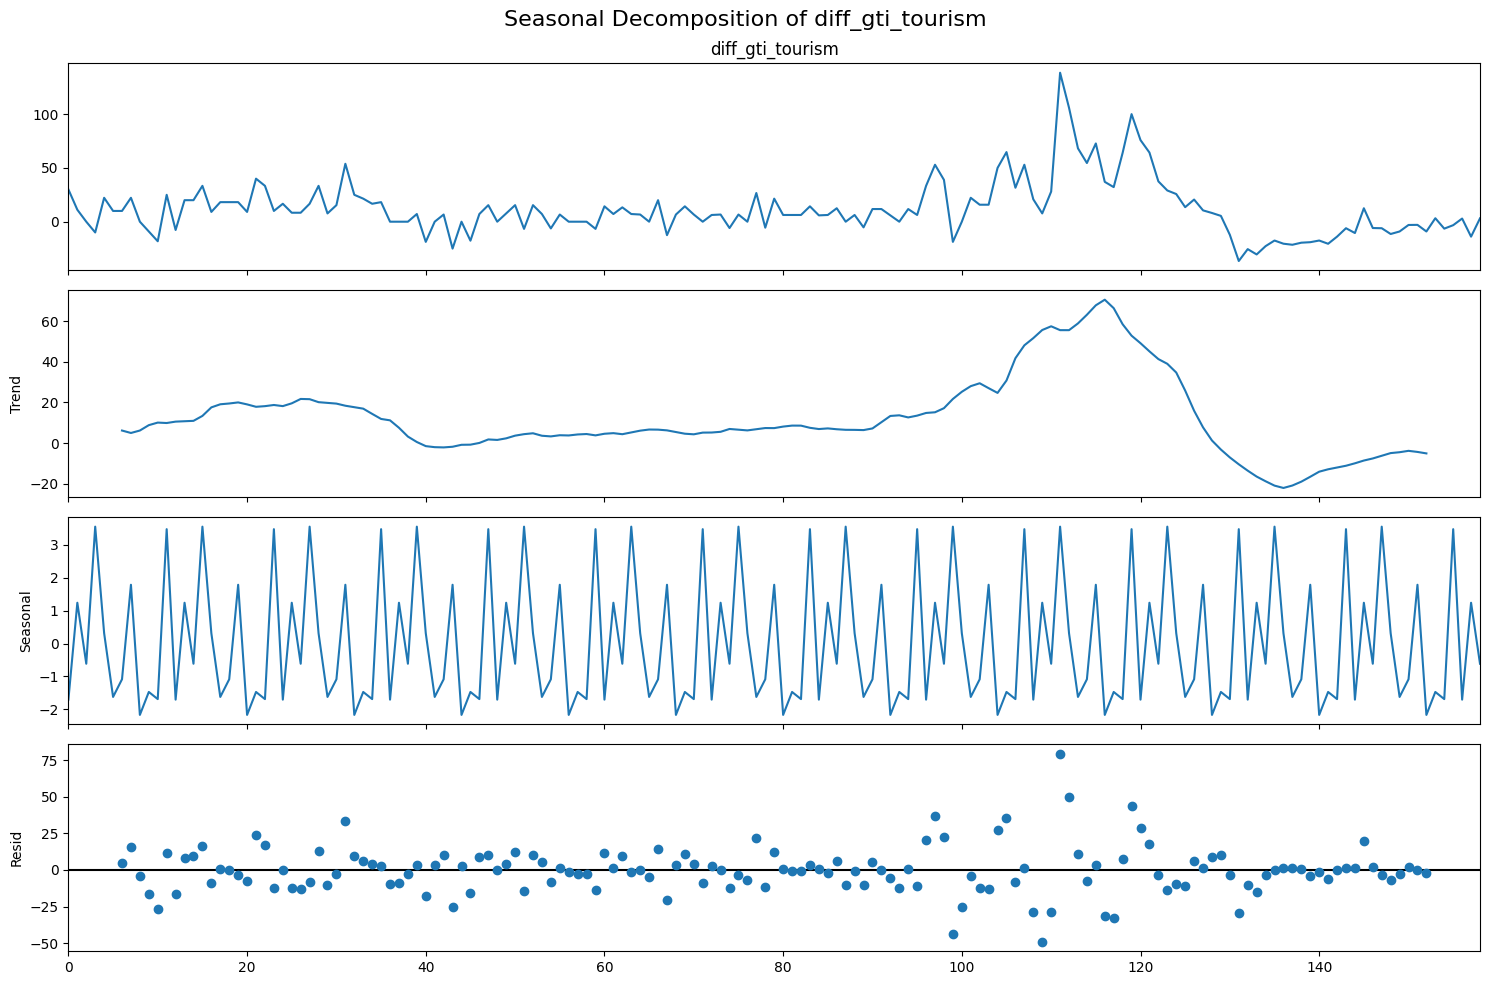

Augmented Dickey-Fuller Test for "diff_decom_GTI"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -2.8873309685385378
P-value = 0.04684119273623207
Critical Values:
   1%: -3.4759527332353084
   5%: -2.881548071241103
   10%: -2.577438765246763
Is the series stationary? Yes ✅
-----------------------------------------------


In [ ]:
# --- Set 'date' as index for decomposition ---
# diff_df.set_index('date', inplace=True)

# --- Decompose diff_gti_tourism (already differenced series) ---
result = seasonal_decompose(diff_df['diff_gti_tourism'].dropna(), model='additive', period=12)

# Create seasonally adjusted series
diff_df['diff_decom_gti_tourism'] = diff_df['diff_gti_tourism'] - result.seasonal

# --- Plot decomposition ---
plt.rcParams["figure.figsize"] = (15,10) # increase figure size
result.plot()
plt.suptitle('Seasonal Decomposition of diff_gti_tourism', fontsize=16)
plt.tight_layout()
plt.show()

# --- ADF Test on seasonally adjusted diff_gti_tourism ---
adf_result = adfuller(diff_df['diff_decom_gti_tourism'].dropna())
print(f'Augmented Dickey-Fuller Test for "diff_decom_GTI"')
print('-' * 47)
print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
print(f'Significance Level = 0.05')
print(f'Test Statistic = {adf_result[0]}')
print(f'P-value = {adf_result[1]}')
print('Critical Values:')
for key, val in adf_result[4].items():
    print(f'   {key}: {val}')
print('Is the series stationary? Yes ✅' if adf_result[1] <= 0.05 else 'Is the series stationary? No ❌')
print('-' * 47)

# Optional: Reset index if needed
#diff_df.reset_index(inplace=True)

**Recover the 2012 data in second differencing of GTI using the mean for all months in each year**

In [ ]:
# First, exclude any existing data for 2012 (in case it’s partially present)
df_without_2012 = second_diff_df_clean[second_diff_df_clean['year'] != 2012]

# Calculate the mean second_diff_gti_tourism for each Month across all other years
monthly_means = df_without_2012.groupby('month')['second_diff_gti_tourism'].mean().reset_index()

# Create a new DataFrame for the "estimated" 2012 values
estimated_2012 = monthly_means.copy()
estimated_2012['year'] = 2012

# Reorder columns to match the original
estimated_2012 = estimated_2012[['month', 'year', 'second_diff_gti_tourism']]

# Append the estimated 2012 data to the original DataFrame
second_diff_df_filled = pd.concat([second_diff_df_clean, estimated_2012], ignore_index=True)

# Sort by Year and Month for clarity
second_diff_df_filled.sort_values(by=['year', 'month'], inplace=True)

second_diff_df_filled.reset_index(inplace=True)

# Preview the new DataFrame
print(second_diff_df_filled[second_diff_df_filled['year'] == 2012])

    index  month  year  second_diff_gti_tourism
0     147      1  2012               -26.562563
1     148      2  2012                57.109144
2     149      3  2012               -70.232682
3     150      4  2012              -187.310362
4     151      5  2012               -66.725870
5     152      6  2012               -93.439492
6     153      7  2012               -92.113219
7     154      8  2012               -62.947563
8     155      9  2012                14.504254
9     156     10  2012              -155.640324
10    157     11  2012               -29.423610
11    158     12  2012                18.258871


**Bring in the second diff column to the main df**

In [ ]:
diff_df['diff_diff_gti_tourism'] =second_diff_df_filled['second_diff_gti_tourism']
diff_df

,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,diff_sum_ntl,...,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism
0,2012,1,30.000000,25.688073,1.290666,-4.088195,-4.096190,-4.124803,-4.132794,NaN,...,114.731741,114.731741,199.333825,199.333825,-13.470742,-13.470742,-18.350097,-18.350097,31.702014,-26.562563
1,2012,2,11.111111,23.711340,0.513480,-7.296961,-7.299587,-8.903832,-8.906412,NaN,...,-41.539304,-41.539304,61.140958,61.140958,-16.059580,-16.059580,-12.129582,-12.129582,9.875097,57.109144
2,2012,3,0.000000,21.890547,1.208166,-10.518845,-10.505198,-11.158948,-11.145399,NaN,...,-15.655515,-15.655515,244.821501,244.821501,-12.649809,-12.649809,-11.481426,-11.481426,0.613496,-70.232682
3,2012,4,-10.000000,41.358025,10.939399,1.293312,1.289930,-0.460780,-0.464103,NaN,...,34.610806,34.610806,213.075806,213.075806,-2.512497,-2.512497,-4.997678,-4.997678,-13.543696,-187.310362
4,2012,5,22.222222,23.033708,-0.763781,-1.592064,-1.596399,-5.417543,-5.421711,NaN,...,12.165230,12.165230,-25.284306,-25.284306,3.215140,3.215140,6.405479,6.405479,21.910344,-66.725870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,2024,11,-6.451613,-35.341662,-35.253382,5.883649,5.890439,5.481949,5.488713,11.952894,...,-55.025294,-55.025294,48.775441,45.008974,8.070301,8.070301,4.859368,4.859368,-4.765994,-53.548387
155,2024,12,-3.225806,-34.289038,-34.289038,-1.451080,-1.443155,0.764022,0.772125,-5.857371,...,-36.801800,-36.801800,-25.947799,-25.947799,-1.110346,-1.110346,6.841894,6.841894,-6.693339,-46.774194
156,2025,1,2.941176,-20.837593,-20.837593,-2.970158,-2.960712,2.240401,2.250354,39.671003,...,271.859384,271.859384,-37.475611,-41.153516,-3.713791,-3.713791,1.909422,1.909422,4.643190,-127.941176
157,2025,2,-13.888889,59.296803,59.296803,111.232645,111.506868,116.903508,117.122359,26.275144,...,-16.951705,-16.951705,-17.312561,-14.069916,-0.938073,-0.938073,-0.174563,-0.174563,-15.124903,-211.111111


In [ ]:
diff_df['year_current'] = diff_df['year_current'].astype(int).astype(str)
diff_df['date'] = pd.to_datetime(diff_df['year_current'].astype(str) + '-' + diff_df['month'].astype(str), format='%Y-%m')
diff_df

,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,diff_sum_ntl,...,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism,date
0,2012,1,30.000000,25.688073,1.290666,-4.088195,-4.096190,-4.124803,-4.132794,NaN,...,114.731741,199.333825,199.333825,-13.470742,-13.470742,-18.350097,-18.350097,31.702014,-26.562563,2012-01-01
1,2012,2,11.111111,23.711340,0.513480,-7.296961,-7.299587,-8.903832,-8.906412,NaN,...,-41.539304,61.140958,61.140958,-16.059580,-16.059580,-12.129582,-12.129582,9.875097,57.109144,2012-02-01
2,2012,3,0.000000,21.890547,1.208166,-10.518845,-10.505198,-11.158948,-11.145399,NaN,...,-15.655515,244.821501,244.821501,-12.649809,-12.649809,-11.481426,-11.481426,0.613496,-70.232682,2012-03-01
3,2012,4,-10.000000,41.358025,10.939399,1.293312,1.289930,-0.460780,-0.464103,NaN,...,34.610806,213.075806,213.075806,-2.512497,-2.512497,-4.997678,-4.997678,-13.543696,-187.310362,2012-04-01
4,2012,5,22.222222,23.033708,-0.763781,-1.592064,-1.596399,-5.417543,-5.421711,NaN,...,12.165230,-25.284306,-25.284306,3.215140,3.215140,6.405479,6.405479,21.910344,-66.725870,2012-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,2024,11,-6.451613,-35.341662,-35.253382,5.883649,5.890439,5.481949,5.488713,11.952894,...,-55.025294,48.775441,45.008974,8.070301,8.070301,4.859368,4.859368,-4.765994,-53.548387,2024-11-01
155,2024,12,-3.225806,-34.289038,-34.289038,-1.451080,-1.443155,0.764022,0.772125,-5.857371,...,-36.801800,-25.947799,-25.947799,-1.110346,-1.110346,6.841894,6.841894,-6.693339,-46.774194,2024-12-01
156,2025,1,2.941176,-20.837593,-20.837593,-2.970158,-2.960712,2.240401,2.250354,39.671003,...,271.859384,-37.475611,-41.153516,-3.713791,-3.713791,1.909422,1.909422,4.643190,-127.941176,2025-01-01
157,2025,2,-13.888889,59.296803,59.296803,111.232645,111.506868,116.903508,117.122359,26.275144,...,-16.951705,-17.312561,-14.069916,-0.938073,-0.938073,-0.174563,-0.174563,-15.124903,-211.111111,2025-02-01


### **Save data**

Uncomment when new data has been processed

In [ ]:
# Using dataframe diff_df: save as csv
filename=f"{data_path}/Model Data/{CountryCode}diff_df.csv"
display(filename)
diff_df.to_csv(filename, index=False)

'/content/drive/MyDrive/STI 2026/Day 2-3 - GDP Nowcasting/Data/Model Data/NGAdiff_df.csv'

## **Quarterly aggregation**

Our target GDP growth frequency is quarterly. We need quarterly or lower frequency data.  

<h3><b>❓ What would you do if the available data had higher frequency, i.e., annual data?
</b>

In [ ]:
df_for_rolling=diff_df.copy()
# Convert 'Date' column to datetime type
df_for_rolling['date'] = pd.to_datetime(df_for_rolling['date'])

# Set 'Date' column as index
df_for_rolling.set_index('date', inplace=True)

# Initialize an empty DataFrame to store the results
result_data = []

# Calculate rolling sum and append to result_data
for i in range(0, len(df_for_rolling) - 2, 3):
    window = df_for_rolling.iloc[i:i+3]
    sum_row = window.sum(axis=0)
    sum_row.name = window.index[-1]  # Use the last date in the window as the index
    sum_row.name += pd.DateOffset(months=1)  # Add one month to the index
    result_data.append(sum_row)

# Create DataFrame from result_data
result_df = pd.DataFrame(result_data)

# Reset index
result_df.reset_index(inplace=True)

# Display the result DataFrame
result_df

,index,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,...,diff_mean_pcp,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism
0,2012-04-01,201220122012,6,41.111111,71.289961,3.012313,-21.904000,-21.900974,-24.187583,-24.184606,...,57.536921,57.536921,505.296283,505.296283,-42.180131,-42.180131,-41.961105,-41.961105,42.190607,-39.686101
1,2012-07-01,201220122012,15,22.222222,92.539881,-1.840599,1.779505,1.772327,-6.027770,-6.034733,...,48.731389,48.731389,153.187114,153.187114,9.893282,9.893282,5.672861,5.672861,19.986701,-347.475724
2,2012-10-01,201220122012,24,32.222222,47.391992,-15.655428,-0.089643,-0.085817,-4.083804,-4.080037,...,16.478828,16.478828,-204.260527,-204.260527,1.906892,1.906892,21.087532,21.087532,33.690570,-140.556528
3,2013-01-01,201220122012,33,-2.272727,104.077283,32.747847,16.350655,16.387259,8.500053,8.535730,...,208.307388,208.307388,-125.954631,-125.954631,-2.211707,-2.211707,32.072675,32.072675,-2.585050,-166.805062
4,2013-04-01,201320132013,6,32.307692,70.282661,87.890194,25.157893,25.082265,22.871325,22.796160,...,205.346276,205.346276,-258.360169,-258.360169,33.408287,33.408287,33.411279,33.411279,33.387188,-102.606788
5,2013-07-01,201320132013,15,60.606061,13.125920,16.649810,7.467235,7.484635,13.014072,13.031634,...,-81.974227,-81.974227,-2.725121,-2.725121,10.777805,10.777805,0.385160,0.385160,58.370539,-410.606061
6,2013-10-01,201320132013,24,45.454545,21.829738,-5.519590,-0.953199,-0.940596,-7.456836,-7.444522,...,-46.478883,-46.478883,565.411401,565.411401,-9.174481,-9.174481,-19.193816,-19.193816,46.922893,6.670601
7,2014-01-01,201320132013,33,83.333333,-43.735207,-42.479710,-11.196522,-11.185753,-7.148884,-7.138186,...,78.170642,78.170642,474.143846,474.143846,-1.431950,-1.431950,-21.284111,-21.284111,83.021011,-883.333333
8,2014-04-01,201420142014,6,33.333333,-26.861195,-33.280902,-3.571012,-3.547666,-2.531891,-2.508304,...,-0.591297,-0.591297,109.866109,109.866109,5.846652,5.846652,-0.092040,-0.092040,34.412829,-433.333333
9,2014-07-01,201420142014,15,57.692308,22.534799,8.030626,2.386322,2.368358,2.490070,2.472071,...,81.080710,81.080710,-144.655622,-144.655622,5.069072,5.069072,12.031952,12.031952,55.456786,158.974359


### **Save data**

Uncomment when new data has been processed

In [ ]:
# prompt: Using dataframe diff_df: save as csv
filename=f"{data_path}/Model Data/{CountryCode}_quarter_df.csv"
result_df.to_csv(filename, index=False)

## **Combine with GDP data**

Load GDP growth quarterly data

In [ ]:
file_path2 = f"{data_path}/GDP Data/ngagdp_growth.csv"
# Reset the index
cou_gdp = pd.read_csv(file_path2)
cou_gdp = cou_gdp.reset_index(drop=True)

In [ ]:
cou_gdp

,dates,GDP,GDP_growth
0,2012-04-01,15108.87,4.158733
1,2012-07-01,15285.67,5.455796
2,2012-10-01,15287.92,3.640100
3,2013-01-01,15620.99,4.600034
4,2013-04-01,15901.19,5.244072
5,2013-07-01,16076.03,5.170594
6,2013-10-01,16257.04,6.339123
7,2014-01-01,16612.07,6.344540
8,2014-04-01,16957.92,6.645603
9,2014-07-01,17087.27,6.290359


In [ ]:
final_combined_df1 = result_df.copy()
new_column = cou_gdp['GDP_growth'].copy()
# Add the new column to df1 using .loc to avoid SettingWithCopyWarning
final_combined_df1.loc[:, 'GDP'] = new_column
final_combined_df1.tail()

,index,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,...,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism,GDP
48,2024-04-01,202420242024,6,-3.908669,-3.856199,-3.857971,-95.547610,-44.373085,-95.509549,-40.928544,...,95.864678,87.696363,97.026934,-17.502403,-17.502403,-15.907226,-15.907226,-2.829173,-273.893529,3.143663
49,2024-07-01,202420242024,15,-26.580087,19.097267,18.955709,-17.040362,-17.011761,-15.038930,-15.009525,...,2.791961,57.865846,59.889135,-19.561049,-19.561049,-14.705117,-14.705117,-28.815608,-167.070707,3.195526
50,2024-10-01,202420242024,24,-15.062389,-188.066217,-185.465258,-28.632328,0.987654,-35.424417,-7.329526,...,-25.013640,75.219780,79.279791,-15.552535,-15.552535,-10.434478,-10.434478,-13.594041,-217.080469,4.352861
51,2025-01-01,202420242024,33,-6.451613,-110.427821,-110.095880,11.715487,11.736998,11.796296,11.817849,...,-54.837019,40.436217,33.654146,16.342595,16.342595,30.908788,30.908788,-6.763935,-216.048387,NaN
52,2025-04-01,202520252025,6,-7.822712,46.801992,46.801992,1782.383110,316.079667,1749.373233,319.208814,...,254.907679,-49.839386,-51.391123,-22.281404,-22.281404,-7.286102,-7.286102,-6.743217,-492.177288,NaN


Drop rows with NA values for GDP

In [ ]:
drop_rows = 2
final_combined_df2 = final_combined_df1.iloc[:-drop_rows] # adjust accordingly the number of rows to drop
final_combined_df2

,index,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,...,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism,GDP
0,2012-04-01,201220122012,6,41.111111,71.289961,3.012313,-21.904000,-21.900974,-24.187583,-24.184606,...,57.536921,505.296283,505.296283,-42.180131,-42.180131,-41.961105,-41.961105,42.190607,-39.686101,4.158733
1,2012-07-01,201220122012,15,22.222222,92.539881,-1.840599,1.779505,1.772327,-6.027770,-6.034733,...,48.731389,153.187114,153.187114,9.893282,9.893282,5.672861,5.672861,19.986701,-347.475724,5.455796
2,2012-10-01,201220122012,24,32.222222,47.391992,-15.655428,-0.089643,-0.085817,-4.083804,-4.080037,...,16.478828,-204.260527,-204.260527,1.906892,1.906892,21.087532,21.087532,33.690570,-140.556528,3.640100
3,2013-01-01,201220122012,33,-2.272727,104.077283,32.747847,16.350655,16.387259,8.500053,8.535730,...,208.307388,-125.954631,-125.954631,-2.211707,-2.211707,32.072675,32.072675,-2.585050,-166.805062,4.600034
4,2013-04-01,201320132013,6,32.307692,70.282661,87.890194,25.157893,25.082265,22.871325,22.796160,...,205.346276,-258.360169,-258.360169,33.408287,33.408287,33.411279,33.411279,33.387188,-102.606788,5.244072
5,2013-07-01,201320132013,15,60.606061,13.125920,16.649810,7.467235,7.484635,13.014072,13.031634,...,-81.974227,-2.725121,-2.725121,10.777805,10.777805,0.385160,0.385160,58.370539,-410.606061,5.170594
6,2013-10-01,201320132013,24,45.454545,21.829738,-5.519590,-0.953199,-0.940596,-7.456836,-7.444522,...,-46.478883,565.411401,565.411401,-9.174481,-9.174481,-19.193816,-19.193816,46.922893,6.670601,6.339123
7,2014-01-01,201320132013,33,83.333333,-43.735207,-42.479710,-11.196522,-11.185753,-7.148884,-7.138186,...,78.170642,474.143846,474.143846,-1.431950,-1.431950,-21.284111,-21.284111,83.021011,-883.333333,6.344540
8,2014-04-01,201420142014,6,33.333333,-26.861195,-33.280902,-3.571012,-3.547666,-2.531891,-2.508304,...,-0.591297,109.866109,109.866109,5.846652,5.846652,-0.092040,-0.092040,34.412829,-433.333333,6.645603
9,2014-07-01,201420142014,15,57.692308,22.534799,8.030626,2.386322,2.368358,2.490070,2.472071,...,81.080710,-144.655622,-144.655622,5.069072,5.069072,12.031952,12.031952,55.456786,158.974359,6.290359


Save final combined data frames ready to nowcast

Uncomment when new data is processed

In [ ]:
final_combined_df1.to_csv(f"{data_path}/Model Data/model_data_nga.csv", index=False)
final_combined_df2.to_csv(f"{data_path}/Model Data/model_data2_nga.csv", index=False)

In [ ]:
final_combined_df1.head()

,index,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,...,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism,GDP
0,2012-04-01,201220122012,6,41.111111,71.289961,3.012313,-21.904000,-21.900974,-24.187583,-24.184606,...,57.536921,505.296283,505.296283,-42.180131,-42.180131,-41.961105,-41.961105,42.190607,-39.686101,4.158733
1,2012-07-01,201220122012,15,22.222222,92.539881,-1.840599,1.779505,1.772327,-6.027770,-6.034733,...,48.731389,153.187114,153.187114,9.893282,9.893282,5.672861,5.672861,19.986701,-347.475724,5.455796
2,2012-10-01,201220122012,24,32.222222,47.391992,-15.655428,-0.089643,-0.085817,-4.083804,-4.080037,...,16.478828,-204.260527,-204.260527,1.906892,1.906892,21.087532,21.087532,33.690570,-140.556528,3.640100
3,2013-01-01,201220122012,33,-2.272727,104.077283,32.747847,16.350655,16.387259,8.500053,8.535730,...,208.307388,-125.954631,-125.954631,-2.211707,-2.211707,32.072675,32.072675,-2.585050,-166.805062,4.600034
4,2013-04-01,201320132013,6,32.307692,70.282661,87.890194,25.157893,25.082265,22.871325,22.796160,...,205.346276,-258.360169,-258.360169,33.408287,33.408287,33.411279,33.411279,33.387188,-102.606788,5.244072


In [ ]:
column_list = final_combined_df1.columns.tolist()
print(column_list)

['index', 'year_current', 'month', 'diff_gti_tourism', 'diff_sum_no2', 'diff_mean_no2', 'diff_sum_ndvi', 'diff_mean_ndvi', 'diff_sum_evi', 'diff_mean_evi', 'diff_sum_ntl', 'diff_mean_ntl', 'diff_mean_pcp', 'diff_sum_pcp', 'diff_sum_asi', 'diff_mean_asi', 'diff_sum_ndvi_anomaly', 'diff_mean_ndvi_anomaly', 'diff_sum_vhi', 'diff_mean_vhi', 'diff_decom_gti_tourism', 'diff_diff_gti_tourism', 'GDP']


### **Correlation checks**

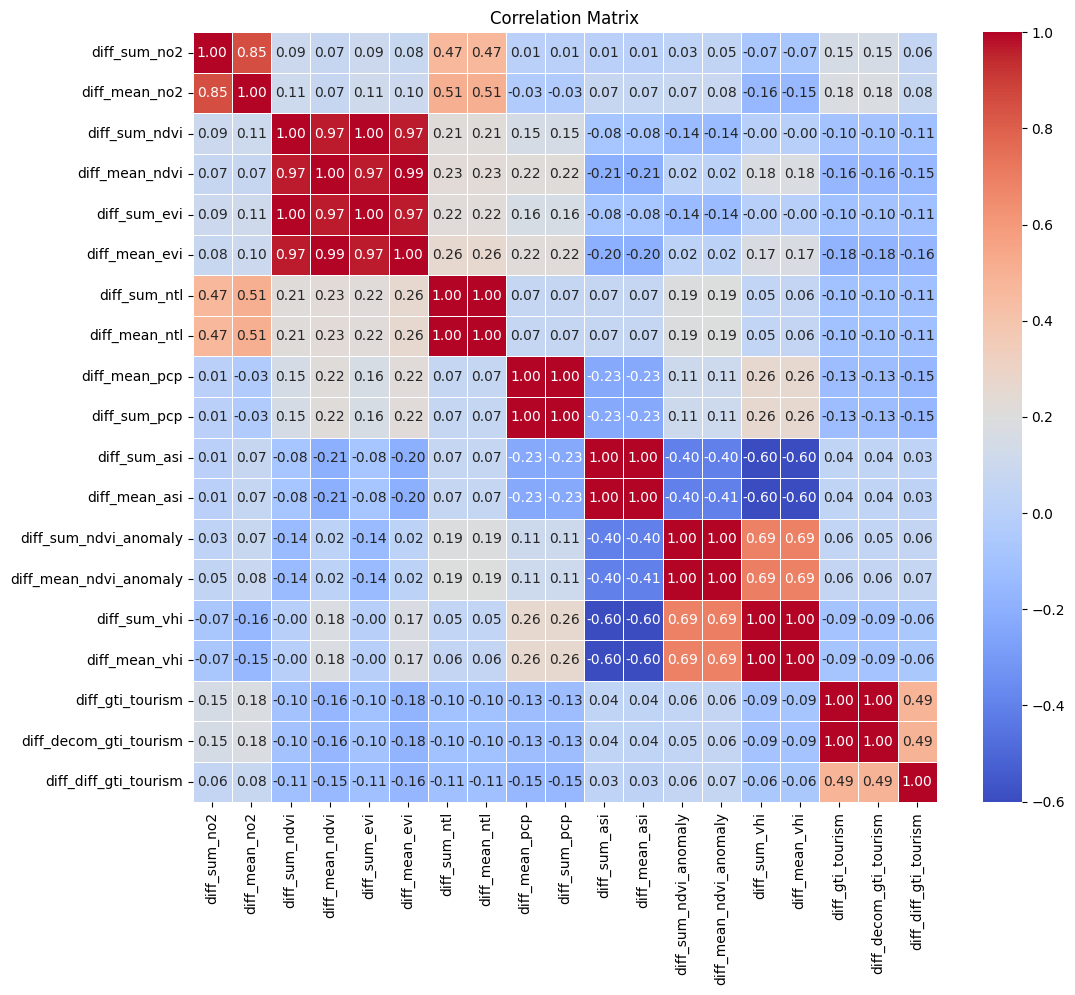

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = final_combined_df1[['diff_sum_no2',
                                'diff_mean_no2',
                                'diff_sum_ndvi',
                                'diff_mean_ndvi',
                                'diff_sum_evi',
                                'diff_mean_evi',
                                'diff_sum_ntl',
                                'diff_mean_ntl',
                                #'GDP',
                                'diff_mean_pcp',
                                'diff_sum_pcp',
                                'diff_sum_asi',
                                'diff_mean_asi',
                                'diff_sum_ndvi_anomaly',
                                'diff_mean_ndvi_anomaly',
                                'diff_sum_vhi',
                                'diff_mean_vhi',
                                'diff_gti_tourism',
                                'diff_decom_gti_tourism',
                                'diff_diff_gti_tourism',]].corr()

# Plot the correlation matrix using Seaborn
plt.figure(figsize=(12, 10))  # Adjusted the figure size to fit more columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')

# Save the figure
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches='tight')  # High resolution with tight layout
plt.show()


## Recap

### Summary of the exercise

This notebook focuses on extracting and preprocessing satellite and agricultural data for the purpose of GDP nowcasting for Nigeria.

The notebook prepares a dataset that can be used as input for GDP nowcasting models.

### Discussion questions

1.  What are the potential benefits and limitations of using satellite data and agricultural indicators for GDP nowcasting?
2.  The notebook used simple differencing and decomposition to handle non-stationarity. What other time series techniques could be applied, and when would they be more appropriate?
3.  The notebook imputed missing values in the NTL series using the mean of the same month across other years. What are alternative imputation methods, and how might they impact the results?
4.  The notebook aggregated the monthly data to quarterly using a rolling sum. What other aggregation methods could be considered, and how might they affect the relationship with quarterly GDP growth?
5.  Based on the correlation matrix, which indicators appear to have the strongest linear relationship with each other, and how might this information guide feature selection for a nowcasting model?

Note regarding the **Day/Night Band (DNB)** data from the nighttime lights repository: provided by EOG group in Colorado School of Mines. We resorted to it when VIIRS Lunar Gap-Filled BRDF Nighttime Lights version 1 was discontinued, however, it also has a long lag (last update since March). There is no point in including it in our data unless we need to fill the gaps systematically.  VIIRS Lunar Gap-Filled BRDF Nighttime Lights version 2 is up-to-date.
Source: https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMCFG

https://www.earthdata.nasa.gov/topics/human-dimensions/nighttime-lights